# Customer Support — Resolution Time Regression

## Step 1: Problem Definition

Define the objective of predicting the **resolution time** (in hours) for a customer support ticket. Estimating resolution times helps set accurate expectations for customers and allows support managers to allocate staffing resources more effectively.


In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

sns.set_theme(style='whitegrid')
print('Project root:', PROJECT_ROOT)

Project root: c:\Users\jegad\projects\CustomerSupportAnalytics


## Step 2: Data Collection

Import the raw historical ticket data from our database connection. The model needs to analyze past tickets, specifically looking at their initial details and how long they took to resolve, to build its predictive logic.


In [2]:
from src.data_loader import load_tickets
raw_df = load_tickets(use_db=True)
raw_df.head()

Loaded 200000 rows from database.


,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,None,Debit Card,Spanish,Evening,3,Corporate


## Step 3: Data Cleaning

Drop columns that give away the answer, such as resolution notes, status, resolved date, and satisfaction score. These fields are created at the *end* of a ticket's lifecycle. We must predict resolution time based purely on what is known at the *start* (ticket creation).


In [3]:
from src.preprocessor import clean_data
cleaned_df = clean_data(raw_df, task_type='regression')
cleaned_df['resolution_time_hours'].describe()

count    200000.000000
mean        120.539718
std          68.969143
min           1.000000
25%          60.810000
50%         120.450000
75%         180.260000
max         240.000000
Name: resolution_time_hours, dtype: float64

### EDA: Resolution time distribution

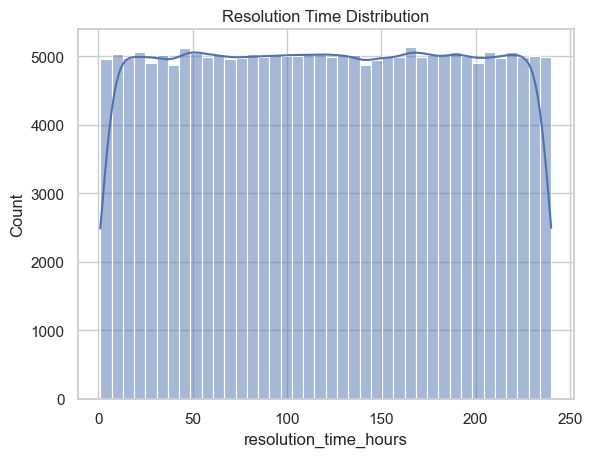

In [4]:
import seaborn as sns
sns.histplot(cleaned_df['resolution_time_hours'], kde=True, bins=40)
plt.title('Resolution Time Distribution')
plt.show()

## Step 4: Feature Engineering

Cap extreme outliers in resolution time and generate date-based features, while retaining text features for TF-IDF. Outliers (like a ticket left open for a year) can drastically skew a regression model. Capping them helps the model make more realistic time predictions.


In [5]:
from src.preprocessor import engineer_features
from src.label_engineering import derive_resolution_hours
import numpy as np

fe_df = engineer_features(cleaned_df, task_type='regression')
fe_df = fe_df.sample(min(30000, len(fe_df)), random_state=42)
fe_df['resolution_time_hours'] = derive_resolution_hours(fe_df)
print('Rows:', len(fe_df))

Rows: 30000


## Step 5: Train-Test Split

Split the data and apply a log-transformation (`expm1`) to the target resolution time variable. Resolution times are often heavily skewed (many quick fixes, a few very long ones). Log-transforming normalizes this spread, making it much easier for the model to learn accurately.


In [6]:
from sklearn.model_selection import train_test_split

X = fe_df.drop(columns=['resolution_time_hours'])
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].fillna('Unknown')
y = np.log1p(fe_df['resolution_time_hours'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape)

Train: (24000, 28)


## Step 6: Model Selection

Compare different regression models, including Linear Regression, Random Forest, and MLP Neural Networks. Predicting a continuous number (hours) requires specific regression algorithms. We test several to find the one with the lowest error rate for our specific dataset.


In [7]:
from sklearn.metrics import r2_score, mean_squared_error
from src.model_trainer import get_regression_pipelines

for name, pipe in get_regression_pipelines(X_train).items():
    pipe.fit(X_train, y_train)
    pred = np.expm1(pipe.predict(X_test))
    true = np.expm1(y_test)
    print(f"{name}: R2={r2_score(true, pred):.4f}  RMSE={np.sqrt(mean_squared_error(true, pred)):.2f}")

Linear Regression: R2=0.8342  RMSE=13.10
Random Forest: R2=0.9913  RMSE=3.01
Neural Network (MLP): R2=0.9486  RMSE=7.29


## Step 7: Model Training

Fit the chosen Random Forest regressor on the training data. Random Forests are robust to non-linear relationships, allowing the model to learn complex interactions (like how a specific product issue combined with a specific channel affects time).


In [8]:
reg = get_regression_pipelines(X_train)['Random Forest']
reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

## Step 8: Model Evaluation

Evaluate the model using R-squared (R2) and Mean Squared Error (MSE), reversing the log transform to see the error in actual hours. We need to know our margin of error in real terms (e.g., we are off by 2 hours on average) to ensure the predictions are reliable enough for business use.


R2: 0.9912582199536504


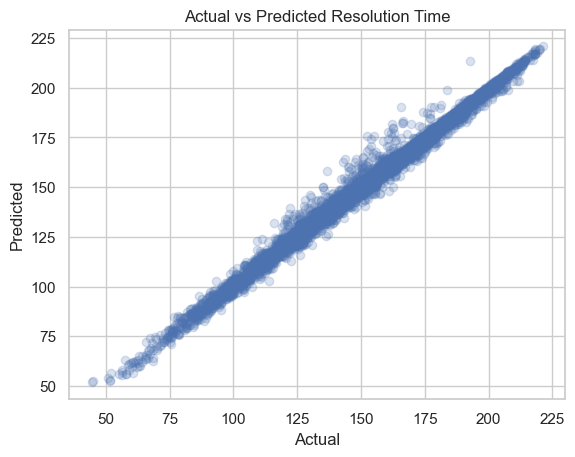

In [9]:
y_pred = np.expm1(reg.predict(X_test))
y_true = np.expm1(y_test)
print('R2:', r2_score(y_true, y_pred))
plt.scatter(y_true, y_pred, alpha=0.2)
plt.xlabel('Actual'); plt.ylabel('Predicted')
plt.title('Actual vs Predicted Resolution Time')
plt.show()

## Step 9: Model Tuning

Set up a GridSearchCV process to fine-tune the Random Forest regressor. Adjusting parameters like tree depth or the number of estimators can significantly reduce our prediction error (MSE).


In [10]:
print('Define param_grid for regressor tuning as needed.')

Define param_grid for regressor tuning as needed.


## Step 10: Deployment

Export the regression model and its preprocessing pipeline to a serialized file. This allows the Streamlit dashboard to load the model instantly and provide live resolution time estimates for new tickets.


In [11]:
import joblib
from src.paths import get_models_dir

r2 = r2_score(y_true, y_pred)
bundle = {'model': reg, 'model_name': 'Random Forest', 'r2': r2, 'log_target': True}
joblib.dump(bundle, os.path.join(get_models_dir(), 'regression_model.pkl'))
print('Saved regression model. R2=', r2)

Saved regression model. R2= 0.9912582199536504
